tensor([[0.5182]], requires_grad=True)


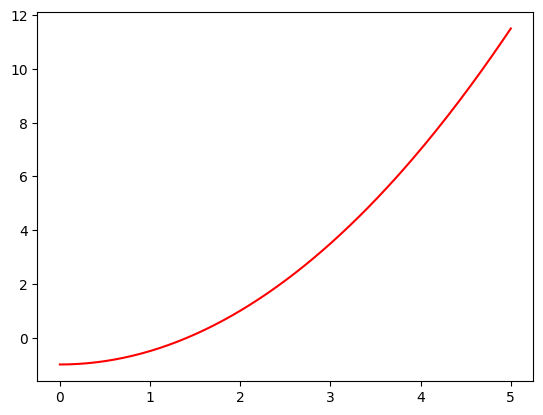

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch

x=torch.tensor(np.linspace(0,5,200))
y=-1+0.5*x**2

a=torch.rand(size=(1,1), requires_grad=True)
b=torch.rand(size=(1,1), requires_grad=True)
lr=1e-4
plt.plot(x,y,'-r',label='Datos originales')

print(a)

In [ ]:
y_est=a+b*x**2
error=torch.mean((y_est-y)**2)
print('error actual: ',error)
a.grad=None
b.grad=None

error.backward()
print(a.grad, b.grad)
a=a-lr*a.grad
b=b-lr*b.grad
y_est=a+b*x**2
error=torch.mean((y_est-y)**2)
print('Nuevo error: ', error)


error actual:  tensor(7.3629, dtype=torch.float64, grad_fn=<MeanBackward0>)
tensor([[-7.1814]]) tensor([[-169.4821]])
Nuevo error:  tensor(6.4401, dtype=torch.float64, grad_fn=<MeanBackward0>)


0 11.558259070507422
5000 0.22512917307814878
10000 0.0926569966318949
15000 0.038135332037975436
20000 0.015695643972765298
25000 0.0064600487036901464
30000 0.0026588619045081877
35000 0.0010943794899281217
40000 0.00045043586576945315
45000 0.00018541037508109498


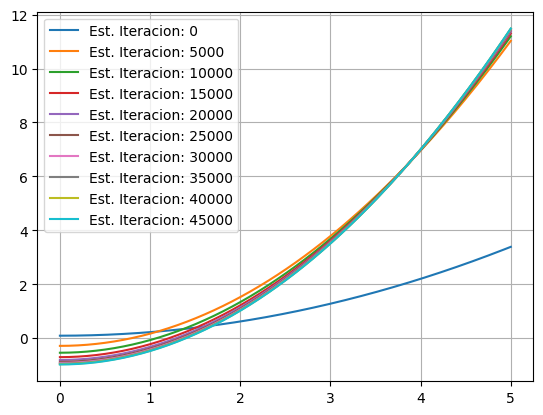

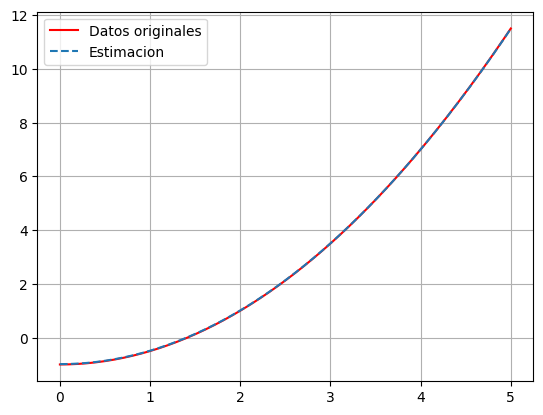

In [ ]:
a=torch.rand(size=(1,1), requires_grad=True)
b=torch.rand(size=(1,1), requires_grad=True)

for i in range(50000):
  loss=((y-(a+b*x**2))**2).mean()
  if(i%5000==0):
    print(i,loss.item())
    with torch.no_grad():
      y_est=(a+b*x**2).numpy().ravel()
      plt.plot(x.numpy(),y_est,'-',label='Est. Iteracion: '+str(i))

  a.grad=None
  b.grad=None
  loss.backward()
  with torch.no_grad():
    a-=lr*a.grad
    b-=lr*b.grad
plt.grid()
plt.legend()

plt.figure()
plt.plot(x,y,'-r',label='Datos originales')
with torch.no_grad():
  y_est=(a+b*x**2).numpy().ravel()
  plt.plot(x.numpy(),y_est,'--',label='Estimacion')
plt.grid()
plt.legend()

In [ ]:
b

tensor([[0.4990]], requires_grad=True)